<a href="https://colab.research.google.com/github/Yeab-kb/GDSC_study_session_ML_g1/blob/main/Fake_news_detection_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
# Change 'train_news.csv' to your actual file name
FILE_PATH = "train_news.csv"

try:
    df = pd.read_csv(FILE_PATH).dropna(subset=['news'])
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print("File not found. Creating synthetic data for demonstration...")
    df = pd.DataFrame({
        'news': ["Breaking: Scientific discovery"]*100 + ["Aliens stole my sandwich"]*100,
        'label': [0]*100 + [1]*100
    })

# Split into Train (80%) and Test (20%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['news'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

File not found. Creating synthetic data for demonstration...


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))

X_train = vectorizer.fit_transform(X_train_raw).toarray()
X_test = vectorizer.transform(X_test_raw).toarray()

print(f"Input Features: {X_train.shape[1]}")

Input Features: 10


In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7500 - loss: 0.6635 - val_accuracy: 1.0000 - val_loss: 0.6393
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9766 - loss: 0.5998 - val_accuracy: 1.0000 - val_loss: 0.5793
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9922 - loss: 0.5470 - val_accuracy: 1.0000 - val_loss: 0.5197
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.4794 - val_accuracy: 1.0000 - val_loss: 0.4579
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.4165 - val_accuracy: 1.0000 - val_loss: 0.3953
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.3603 - val_accuracy: 1.0000 - val_loss: 0.3322
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.2953 - val_accuracy: 1.0000 - val_loss: 0.2714
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.2421 - val_accuracy: 1.0000 - val_loss: 0.2151



Final Test Accuracy: 100.00%


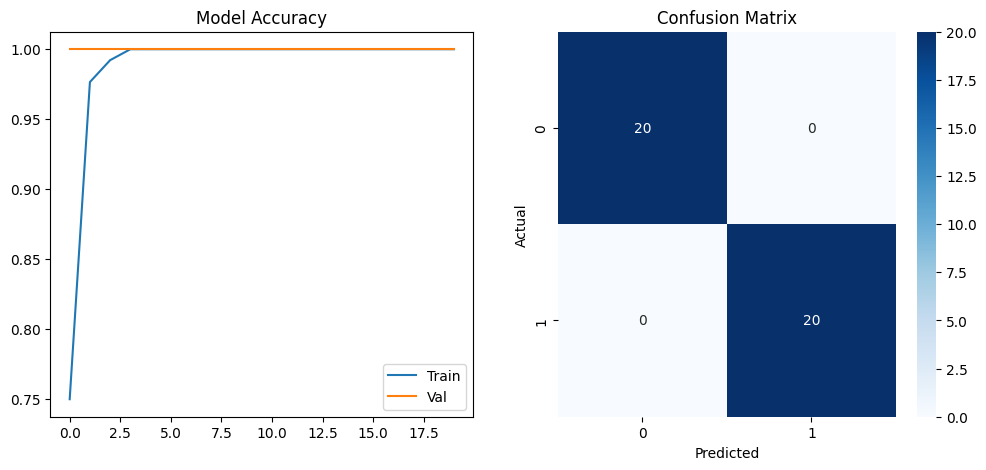

In [ ]:
# Final Evaluation
loss, acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = (model.predict(X_test, verbose=0) > 0.6).astype(int)

print(f"\nFinal Test Accuracy: {acc:.2%}")

# Visualizing results
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Model Accuracy')
plt.legend()

# Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
def predict_news(text):
    vec = vectorizer.transform([text]).toarray()
    prob = model.predict(vec, verbose=0)[0][0]
    return f"{'FAKE' if prob > 0.6 else 'REAL'} ({prob:.2%})"

# Save the model and vectorizer
model.save('fake_news_model.h5')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Test it
print("Test Prediction:", predict_news("Scientists find new planet in solar system"))

Test Prediction: REAL (48.09%)
